# Allen scRNA-seq Marker Discovery for Layer 2/3 Inhibitory Neurons

This notebook implements the workflow for identifying minimal marker gene panels to distinguish GABAergic interneuron subtypes in Layer 2/3 for serial smFISH experiments.

**Analysis workflow:**
1. Load Allen Brain Map scRNA-seq data (VISp/V1)
2. Filter to Layer 2/3 inhibitory neurons
3. Identify differentially expressed genes
4. Select optimal marker panel
5. Validate classification performance

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom modules
import data_loader
import cell_filter
import diff_expression
import marker_selection
import visualization

# Configure plotting
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(8, 6))
sns.set_style('whitegrid')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load Allen Brain Map Data

Download data from: https://celltypes.brain-map.org/rnaseq/mouse/v1-alm

Required files:
- Cell metadata (annotations, layer, cluster assignments)
- Expression matrix (TPM or counts)

In [2]:
# Paths to Allen Brain Map VISp SMART-seq data
DATA_DIR = '/mnt/nasquatch/data/RNAseq/allenV1_SMART-seq'

expression_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_exon-matrix.csv'
metadata_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_samples-columns.csv'
genes_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_genes-rows.csv'

# Cache filtered results to disk — re-runs load in seconds instead of minutes
cell_filter.set_cache_dir(f'{DATA_DIR}/cache')

# Load metadata first (9 MB, fast), filter to 1173 target cells, then read
# only those columns from the 1.5 GB expression CSV — avoids the full matrix.
# Allen brain_subregion values are 'L2/3', 'L5', 'L6', etc.
adata_l23_inh = data_loader.load_allen_filtered(
    metadata_path=metadata_path,
    expression_path=expression_path,
    target_class='GABAergic',
    target_layers=[],
    genes_path=genes_path,
    layer_name='counts',
)
adata_l23_inh

Loading metadata from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_samples-columns.csv...
Loaded metadata: 15413 cells × 49 columns
Key columns: ['class', 'subclass', 'cluster']
Metadata filter: 6125 of 15413 cells selected (class='GABAergic', layers=[])
Loading expression matrix from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_exon-matrix.csv...
  Reading 6125 of 15413 cell columns...
Loaded expression: 6125 cells × 45768 genes
Creating AnnData with 6125 cells

Cell classes: 1
class
GABAergic    6125
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 6125 × 45768
    obs: 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermediate_call'
    l

In [5]:
# Explore the filtered dataset
print("Available metadata columns:")
print(adata_l23_inh.obs.columns.tolist())

print("\n" + "="*50)
print("Layer 2/3 GABAergic cell type annotations:")
print("="*50)

print("\nSubclass distribution:")
print(adata_l23_inh.obs['subclass'].value_counts())

print("\nCluster distribution:")
print(adata_l23_inh.obs['cluster'].value_counts())

Available metadata columns:
['sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermediate_call']

Layer 2/3 GABAergic cell type ann

In [ ]:


adata_l23_inh.layers['counts']

(6125, 45768)

## 2. Explore Dataset

Examine cell type composition and layer distribution

          n_cells  percentage
subclass                     
Sst          1741       28.42
Vip          1728       28.21
Pvalb        1337       21.83
Lamp5        1122       18.32
Sncg          125        2.04
Meis2          45        0.73
Serpinf1       27        0.44


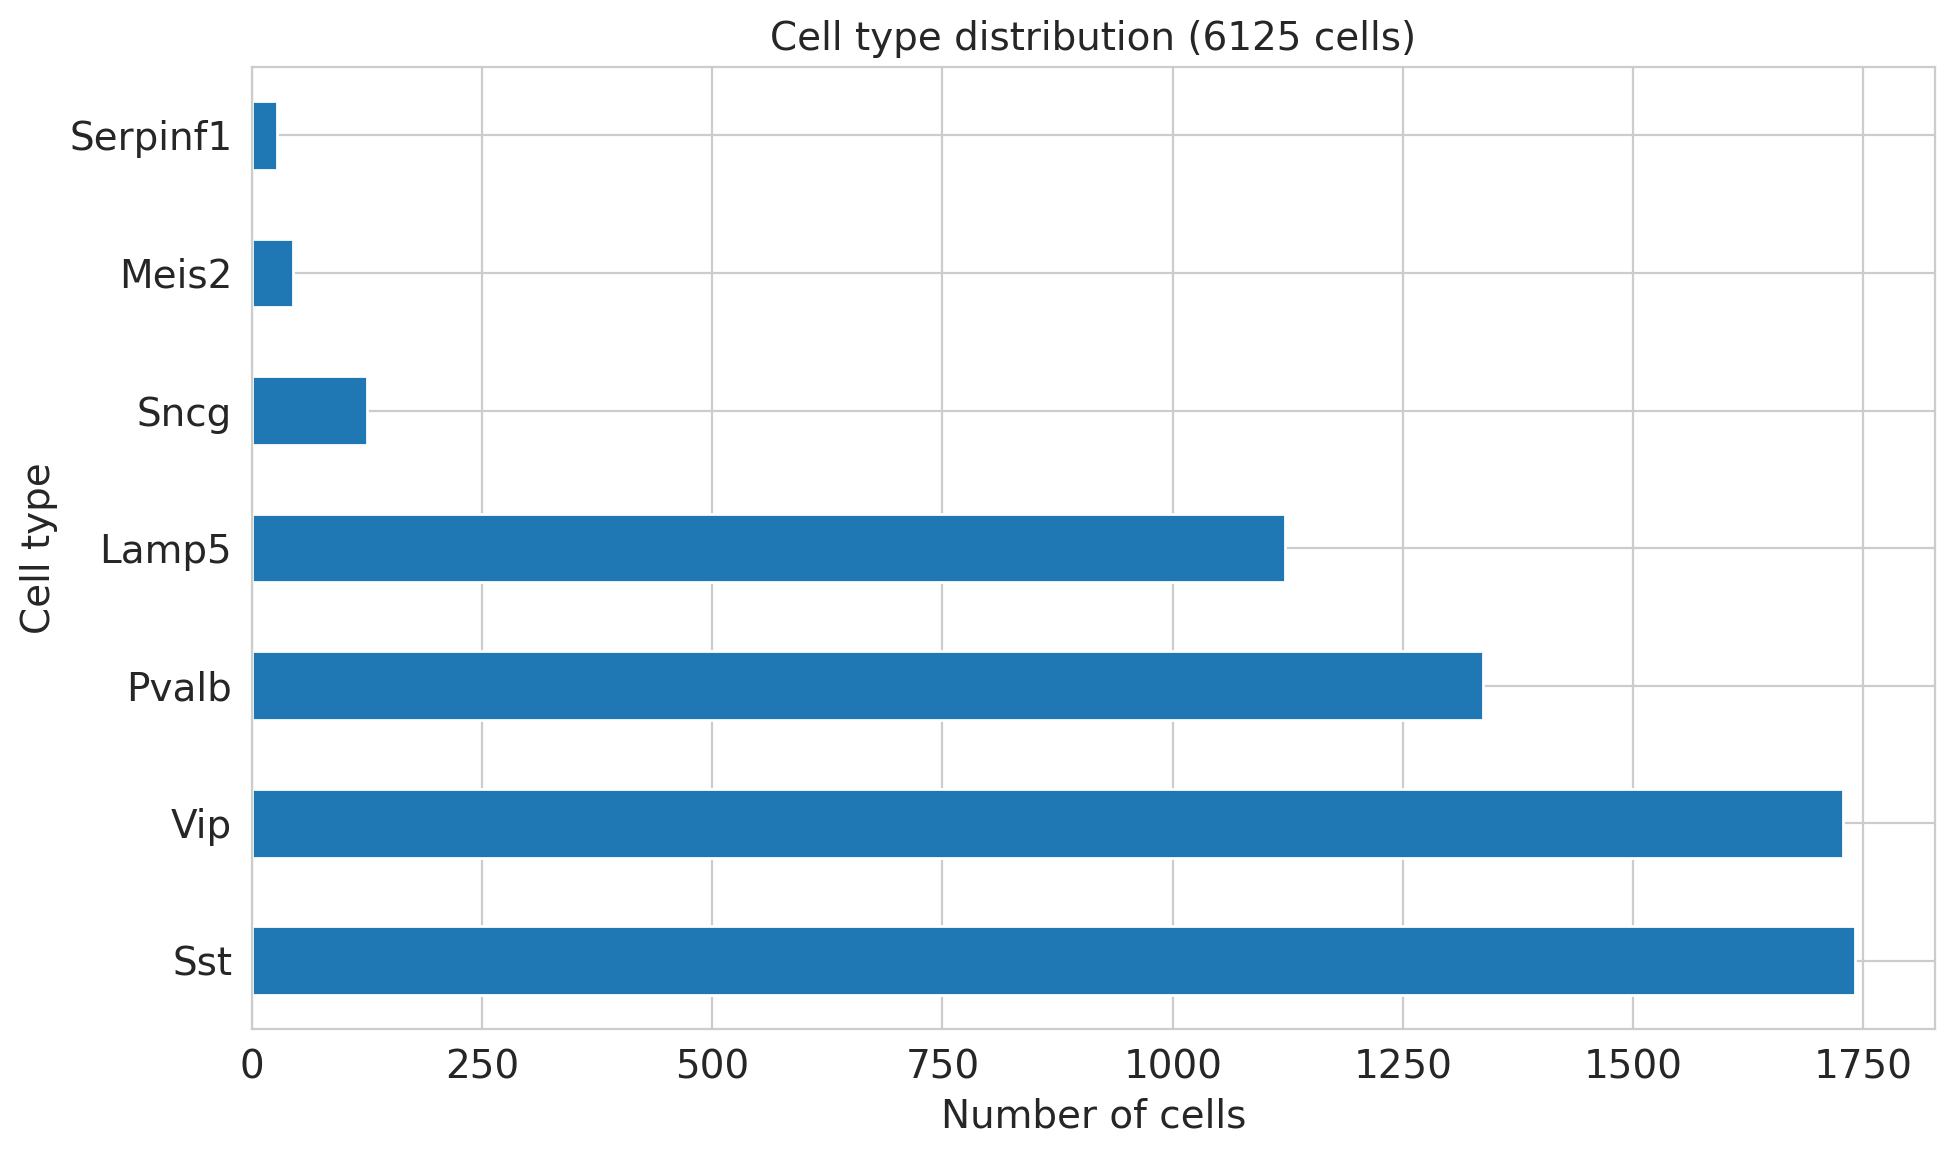

In [4]:
# Cell-level filtering already applied during load (GABAergic + L2/3).
# Summarize subclass composition of the loaded dataset.
summary = cell_filter.get_cell_type_summary(adata_l23_inh, groupby='subclass')
print(summary)

fig = visualization.plot_celltype_distribution(adata_l23_inh, groupby='subclass')
plt.show()

## 3. Filter to Layer 2/3 Inhibitory Neurons

Subset data to GABAergic interneurons in Layer 2/3

In [14]:
# Filter low-expressed genes
# With count data, require at least 1 count in 10+ cells
adata_l23_inh = cell_filter.filter_expressed_genes(
    adata_l23_inh,
    min_cells=10,
    min_counts=1.0
)

# Optional: Filter to high-quality cells only
adata_l23_inh = cell_filter.filter_high_quality(adata_l23_inh, exclude_no_class=True)

print(f"\nFiltered data: {adata_l23_inh.n_obs} cells × {adata_l23_inh.n_vars} genes")

Gene filter: 45768 → 26776 (18992 removed)
Excluding 'No Class' cells: 0 removed

Filtered data: 6125 cells × 26776 genes


## 4. Quality Control and Gene Filtering

Filter genes with sufficient expression for smFISH detection

In [15]:
# Compute mean expression per subclass
mean_expr = diff_expression.compute_cluster_means(
    adata_l23_inh,
    groupby='cluster',
    use_layer='counts'
)

# Compute detection frequency (% cells with >0 counts)
freq = diff_expression.compute_cluster_frequency(
    adata_l23_inh,
    groupby='cluster',
    threshold=0.0,
    use_layer='counts'
)

# Run differential expression
de_results = diff_expression.find_differential_genes(
    adata_l23_inh,
    groupby='cluster',
    method='wilcoxon',
    n_genes=200,
    use_layer='counts'
)

# View top results per subclass
print("\nTop DE genes per subclass:")
for subclass in de_results['group'].unique()[:5]:
    top_genes = de_results[de_results['group'] == subclass].head(5)['gene'].tolist()
    print(f"  {subclass}: {', '.join(top_genes)}")

Running differential expression: wilcoxon, groupby=cluster


/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/mnt/colab/

Found DE genes for 61 groups

Top DE genes per subclass:
  Lamp5 Fam19a1 Pax6: 69352, 70155, 97998, 66561, 68262
  Lamp5 Fam19a1 Tmem182: 97998, 70155, 69352, 66561, 67455
  Lamp5 Krt73: 20284, 18508, 14261, 269831, 244745
  Lamp5 Lhx6: 15902, 12950, 22253, 117148, 207495
  Lamp5 Lsp1: 76161, 21835, 21955, 235415, 109648


/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:440: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:450: PerformanceWarning: Da

## 5. Differential Expression Analysis

Identify genes that distinguish inhibitory subtypes

In [ ]:
# Find marker candidates meeting smFISH criteria
# Thresholds for count data (not TPM)
marker_candidates = diff_expression.find_marker_candidates(
    adata_l23_inh,
    groupby='cluster',
    min_mean_expression=10.0,   # At least 10 mean counts
    min_detection_freq=25.0,    # Detected in 25%+ cells
    min_log2fc=1.0,             # 2-fold enrichment
    max_pval_adj=0.05,
    use_layer='counts'
)

print(f"\nFound {len(marker_candidates)} marker candidates")
print("\nTop 20 marker candidates:")
marker_candidates.head(20)

Finding marker candidates for cluster...
  Thresholds: expr>=10.0, freq>=25.0%, log2fc>=1.0, padj<=0.05
Running differential expression: wilcoxon, groupby=cluster


/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/mnt/colab/

Found DE genes for 61 groups


## 6. Identify Marker Candidates

Find genes with high expression, specificity, and statistical significance

In [ ]:
# Select top markers per cell type
top_markers = marker_candidates.groupby('cluster').head(3)['gene'].unique().tolist()

print(f"Top markers for visualization: {len(top_markers)} genes")

# Plot heatmap of mean expression
fig = visualization.plot_marker_heatmap(
    adata_l23_inh,
    genes=top_markers[:15],
    groupby='subclass'
)
plt.show()

# Plot dotplot (expression + frequency)
sc.pl.dotplot(adata_l23_inh, var_names=top_markers[:15], groupby='subclass')
plt.show()

## 7. Visualize Marker Candidates

Examine expression patterns of top markers

In [ ]:
# Get top candidates per cell type
celltype_markers = marker_selection.optimize_panel_per_celltype(
    adata_l23_inh,
    marker_candidates,
    groupby='subclass',
    n_markers_per_type=3
)

# Compile candidate pool for optimization
candidate_pool = marker_selection.get_combined_marker_pool(celltype_markers)
print(f"\nCandidate pool for optimization: {len(candidate_pool)} genes")

# Greedy forward selection for optimal panel
optimal_markers = marker_selection.greedy_marker_selection(
    adata_l23_inh,
    candidate_genes=candidate_pool,
    groupby='subclass',
    max_markers=10,
    min_accuracy=0.90,
    use_layer='counts'
)

print(f"\nOptimal marker panel ({len(optimal_markers)} genes):")
print(optimal_markers)

In [ ]:
# Start with top candidates per cell type
# celltype_markers = marker_selection.optimize_panel_per_celltype(
#     adata_l23_inh,
#     marker_candidates,
#     groupby='subclass',
#     n_markers_per_type=2
# )

# Compile initial candidate pool
# candidate_pool = []
# for markers in celltype_markers.values():
#     candidate_pool.extend(markers)
# candidate_pool = list(set(candidate_pool))
# print(f"\nCandidate pool: {len(candidate_pool)} genes")

In [ ]:
# Score final panel with more CV folds
final_accuracy = marker_selection.score_marker_panel(
    adata_l23_inh,
    genes=optimal_markers,
    groupby='subclass',
    cv=10,
    use_layer='counts'
)
print(f"Final panel accuracy (10-fold CV): {final_accuracy:.4f}")

# Compute pairwise separability
separability = marker_selection.calculate_pairwise_separability(
    adata_l23_inh,
    genes=optimal_markers,
    groupby='subclass',
    use_layer='counts'
)

# Plot separability heatmap
fig = visualization.plot_separability_heatmap(separability)
plt.show()

# Visualize final markers
fig = visualization.plot_marker_heatmap(
    adata_l23_inh,
    genes=optimal_markers,
    groupby='subclass',
    figsize=(10, max(4, len(optimal_markers) * 0.5))
)
plt.savefig('../outputs/figures/final_marker_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Violin plots for selected markers
sc.pl.violin(adata_l23_inh, keys=optimal_markers[:6], groupby='subclass', rotation=45)
plt.show()

In [ ]:
# Score final panel
# final_accuracy = marker_selection.score_marker_panel(
#     adata_l23_inh,
#     genes=optimal_markers,
#     groupby='subclass',
#     cv=10
# )
# print(f"Final panel accuracy: {final_accuracy:.4f}")

# Compute pairwise separability
# separability = marker_selection.calculate_pairwise_separability(
#     adata_l23_inh,
#     genes=optimal_markers,
#     groupby='subclass'
# )

# Plot separability heatmap
# fig = visualization.plot_separability_heatmap(separability)
# plt.show()

In [ ]:
# Export marker panel with statistics
marker_selection.export_marker_panel(
    genes=optimal_markers,
    output_path='../outputs/markers/optimal_marker_panel.csv',
    adata=adata_l23_inh,
    marker_df=marker_candidates,
    groupby='subclass'
)

# Export all candidate markers for reference
marker_candidates.to_csv(
    '../outputs/markers/all_marker_candidates.csv',
    index=False
)
print(f"Exported {len(marker_candidates)} marker candidates")

# Export pairwise separability
separability.to_csv('../outputs/markers/pairwise_separability.csv')
print("Exported pairwise separability matrix")

## 10. Export Results

Save marker panel and statistics for smFISH probe design

In [ ]:
# Export marker panel
# marker_selection.export_marker_panel(
#     genes=optimal_markers,
#     output_path='../outputs/markers/optimal_marker_panel.csv',
#     adata=adata_l23_inh,
#     marker_df=marker_candidates,
#     groupby='subclass'
# )

# Export all candidate markers for reference
# marker_candidates.to_csv(
#     '../outputs/markers/all_marker_candidates.csv',
#     index=False
# )

# Export pairwise separability
# separability.to_csv(
#     '../outputs/markers/pairwise_separability.csv'
# )

## Summary

This notebook identified a minimal marker gene panel for distinguishing Layer 2/3 inhibitory neuron subtypes using:
- Differential expression analysis
- Expression-based filtering (smFISH criteria)
- Greedy forward feature selection
- Cross-validated classification

The selected markers can be used for serial smFISH probe design to spatially resolve GABAergic interneuron diversity in cortical Layer 2/3.